In [3]:
#Importing Libraries
import pandas as pd
import numpy as np

from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from dotenv import load_dotenv

import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME")

DATABASE_URL = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD if DB_PASSWORD else None,
    host=DB_HOST,
    port=int(DB_PORT),
    database=DB_NAME,
)

engine = create_engine(DATABASE_URL)

print("PostgreSQL connection successful.")

PostgreSQL connection successful.


In [5]:
query = """
SELECT *
FROM prepared_ml_dataset
ORDER BY weather_time
"""

df = pd.read_sql(query, engine)

print(df.shape)

df.head()

(175420, 24)


,id,city,latitude,longitude,weather_time,temperature,humidity,precipitation,rain,pressure,...,day,month,day_of_week,precipitation_lag_1,humidity_lag_1,cloud_cover_lag_1,temp_rolling_3,humidity_rolling_3,rain_next_hour,prepared_at
0,1,Athlone,53.4239,-7.9407,2024-01-01 02:00:00,5.2,85.0,0.0,0.0,996.6,...,1,1,0,0.0,87.0,15.0,5.433333,86.000000,0,2026-05-21 15:33:10.052517
1,35085,Derry,54.9966,-7.3086,2024-01-01 02:00:00,5.3,89.0,0.1,0.1,991.7,...,1,1,0,0.4,88.0,40.0,5.900000,88.333333,0,2026-05-21 15:33:10.052517
2,17543,Cork,51.8985,-8.4756,2024-01-01 02:00:00,4.7,82.0,0.0,0.0,1001.1,...,1,1,0,0.0,73.0,19.0,5.533333,76.000000,0,2026-05-21 15:33:10.052517
3,122795,Limerick,52.6638,-8.6267,2024-01-01 02:00:00,5.5,78.0,0.0,0.0,999.2,...,1,1,0,0.0,77.0,37.0,6.033333,78.666667,0,2026-05-21 15:33:10.052517
4,52627,Dublin,53.3498,-6.2603,2024-01-01 02:00:00,6.0,79.0,0.0,0.0,994.6,...,1,1,0,0.0,79.0,98.0,6.633333,79.333333,0,2026-05-21 15:33:10.052517


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175420 entries, 0 to 175419
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   id                   175420 non-null  int64         
 1   city                 175420 non-null  str           
 2   latitude             175420 non-null  float64       
 3   longitude            175420 non-null  float64       
 4   weather_time         175420 non-null  datetime64[us]
 5   temperature          175420 non-null  float64       
 6   humidity             175420 non-null  float64       
 7   precipitation        175420 non-null  float64       
 8   rain                 175420 non-null  float64       
 9   pressure             175420 non-null  float64       
 10  cloud_cover          175420 non-null  float64       
 11  wind_speed           175420 non-null  float64       
 12  loaded_at            175420 non-null  datetime64[us]
 13  hour                 1754

In [7]:
df.describe()

,id,latitude,longitude,weather_time,temperature,humidity,precipitation,rain,pressure,cloud_cover,...,day,month,day_of_week,precipitation_lag_1,humidity_lag_1,cloud_cover_lag_1,temp_rolling_3,humidity_rolling_3,rain_next_hour,prepared_at
count,175420.000000,175420.000000,175420.000000,175420,175420.000000,175420.000000,175420.000000,175420.000000,175420.000000,175420.000000,...,175420.000000,175420.000000,175420.000000,175420.000000,175420.000000,175420.000000,175420.000000,175420.000000,175420.000000,175420
mean,87710.500000,53.085320,-8.000410,2024-12-31 12:29:59.999999,10.601958,83.441272,0.145124,0.141873,1012.924415,72.817626,...,15.740394,6.520465,2.992133,0.145131,83.440902,72.815979,10.602150,83.440980,0.272666,2026-05-21 15:33:10.052516
min,1.000000,51.898500,-9.504400,2024-01-01 02:00:00,-7.700000,30.000000,0.000000,0.000000,946.100000,0.000000,...,1.000000,1.000000,0.000000,0.000000,30.000000,0.000000,-7.300000,31.000000,0.000000,2026-05-21 15:33:10.052517
25%,43855.750000,52.259300,-8.626700,2024-07-01 19:00:00,7.400000,76.000000,0.000000,0.000000,1005.100000,42.000000,...,8.000000,4.000000,1.000000,0.000000,76.000000,42.000000,7.400000,76.666667,0.000000,2026-05-21 15:33:10.052517
50%,87710.500000,52.967250,-8.208150,2024-12-31 12:30:00,10.800000,86.000000,0.000000,0.000000,1014.100000,99.000000,...,16.000000,7.000000,3.000000,0.000000,86.000000,99.000000,10.800000,86.000000,0.000000,2026-05-21 15:33:10.052517
75%,131565.250000,53.423900,-7.244800,2025-07-02 06:00:00,13.900000,92.000000,0.100000,0.100000,1021.800000,100.000000,...,23.000000,10.000000,5.000000,0.100000,92.000000,100.000000,13.866667,92.000000,1.000000,2026-05-21 15:33:10.052517
max,175420.000000,54.996600,-6.260300,2025-12-31 23:00:00,28.600000,100.000000,12.800000,12.800000,1044.300000,100.000000,...,31.000000,12.000000,6.000000,12.800000,100.000000,100.000000,28.566667,100.000000,1.000000,2026-05-21 15:33:10.052517
std,50639.536448,0.937929,0.953733,NaN,4.691204,11.169963,0.477759,0.469932,12.613131,36.652987,...,8.803041,3.449254,2.000532,0.477764,11.169958,36.653666,4.661375,10.875625,0.445332,NaN


In [8]:
df.isnull().sum()

id                     0
city                   0
latitude               0
longitude              0
weather_time           0
temperature            0
humidity               0
precipitation          0
rain                   0
pressure               0
cloud_cover            0
wind_speed             0
loaded_at              0
hour                   0
day                    0
month                  0
day_of_week            0
precipitation_lag_1    0
humidity_lag_1         0
cloud_cover_lag_1      0
temp_rolling_3         0
humidity_rolling_3     0
rain_next_hour         0
prepared_at            0
dtype: int64

In [9]:
df["rain_next_hour"].value_counts()

rain_next_hour
0    127589
1     47831
Name: count, dtype: int64

In [10]:
df["rain_next_hour"].value_counts(normalize=True) * 100

rain_next_hour
0    72.73344
1    27.26656
Name: proportion, dtype: float64

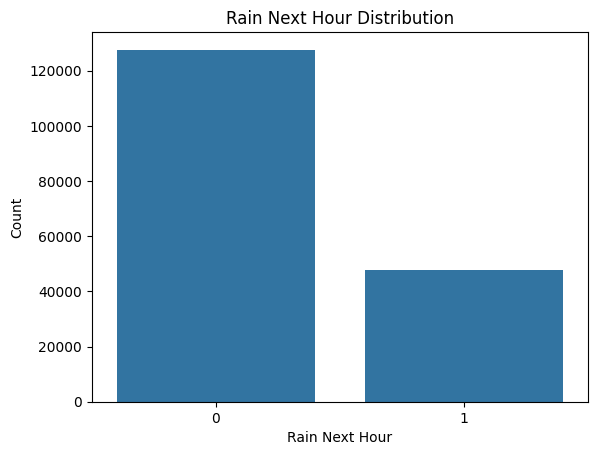

In [11]:
sns.countplot(x="rain_next_hour", data=df)
plt.title("Rain Next Hour Distribution")
plt.xlabel("Rain Next Hour")
plt.ylabel("Count")
plt.show()

In [12]:
drop_columns = [
    "id",
    "weather_time",
    "loaded_at",
    "prepared_at"
]

df = df.drop(columns=drop_columns)

print(df.shape)
df.head()

(175420, 20)


,city,latitude,longitude,temperature,humidity,precipitation,rain,pressure,cloud_cover,wind_speed,hour,day,month,day_of_week,precipitation_lag_1,humidity_lag_1,cloud_cover_lag_1,temp_rolling_3,humidity_rolling_3,rain_next_hour
0,Athlone,53.4239,-7.9407,5.2,85.0,0.0,0.0,996.6,17.0,19.7,2,1,1,0,0.0,87.0,15.0,5.433333,86.000000,0
1,Derry,54.9966,-7.3086,5.3,89.0,0.1,0.1,991.7,56.0,19.5,2,1,1,0,0.4,88.0,40.0,5.900000,88.333333,0
2,Cork,51.8985,-8.4756,4.7,82.0,0.0,0.0,1001.1,59.0,13.8,2,1,1,0,0.0,73.0,19.0,5.533333,76.000000,0
3,Limerick,52.6638,-8.6267,5.5,78.0,0.0,0.0,999.2,18.0,18.0,2,1,1,0,0.0,77.0,37.0,6.033333,78.666667,0
4,Dublin,53.3498,-6.2603,6.0,79.0,0.0,0.0,994.6,7.0,32.4,2,1,1,0,0.0,79.0,98.0,6.633333,79.333333,0


In [13]:
encoder = LabelEncoder()

df["city"] = encoder.fit_transform(df["city"])

df.head()

,city,latitude,longitude,temperature,humidity,precipitation,rain,pressure,cloud_cover,wind_speed,hour,day,month,day_of_week,precipitation_lag_1,humidity_lag_1,cloud_cover_lag_1,temp_rolling_3,humidity_rolling_3,rain_next_hour
0,0,53.4239,-7.9407,5.2,85.0,0.0,0.0,996.6,17.0,19.7,2,1,1,0,0.0,87.0,15.0,5.433333,86.000000,0
1,2,54.9966,-7.3086,5.3,89.0,0.1,0.1,991.7,56.0,19.5,2,1,1,0,0.4,88.0,40.0,5.900000,88.333333,0
2,1,51.8985,-8.4756,4.7,82.0,0.0,0.0,1001.1,59.0,13.8,2,1,1,0,0.0,73.0,19.0,5.533333,76.000000,0
3,7,52.6638,-8.6267,5.5,78.0,0.0,0.0,999.2,18.0,18.0,2,1,1,0,0.0,77.0,37.0,6.033333,78.666667,0
4,3,53.3498,-6.2603,6.0,79.0,0.0,0.0,994.6,7.0,32.4,2,1,1,0,0.0,79.0,98.0,6.633333,79.333333,0


In [14]:
X = df.drop("rain_next_hour", axis=1)

y = df["rain_next_hour"]

print(X.shape)
print(y.shape)

(175420, 19)
(175420,)


In [15]:
X.columns

Index(['city', 'latitude', 'longitude', 'temperature', 'humidity',
       'precipitation', 'rain', 'pressure', 'cloud_cover', 'wind_speed',
       'hour', 'day', 'month', 'day_of_week', 'precipitation_lag_1',
       'humidity_lag_1', 'cloud_cover_lag_1', 'temp_rolling_3',
       'humidity_rolling_3'],
      dtype='str')

In [16]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (140336, 19)
Testing Shape: (35084, 19)


In [17]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

print("XGBoost model training completed.")

XGBoost model training completed.


In [18]:
y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


In [19]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.8810853950518756
Precision: 0.8138888888888889
Recall   : 0.7581608280254777
F1 Score : 0.7850370981038747
ROC AUC  : 0.9343120925771348


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92     25036
           1       0.81      0.76      0.79     10048

    accuracy                           0.88     35084
   macro avg       0.86      0.84      0.85     35084
weighted avg       0.88      0.88      0.88     35084



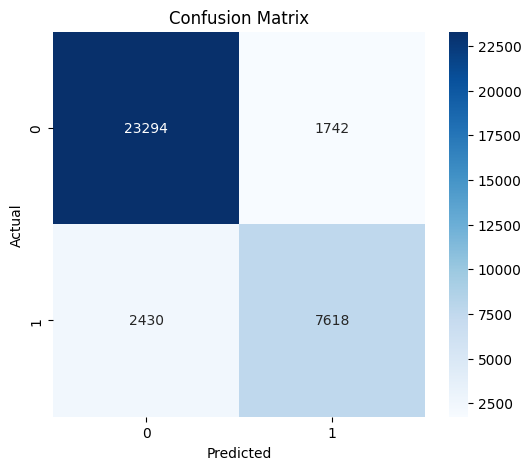

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
5,precipitation,0.814155
6,rain,0.034363
8,cloud_cover,0.027170
14,precipitation_lag_1,0.026650
7,pressure,0.014865
10,hour,0.010546
3,temperature,0.008001
9,wind_speed,0.007829
16,cloud_cover_lag_1,0.006898
2,longitude,0.006679


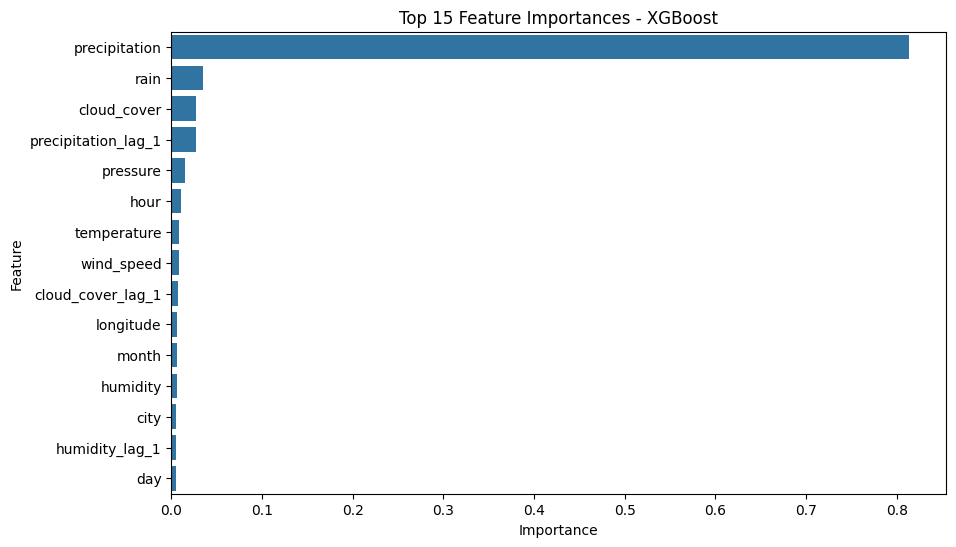

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [25]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/xgboost_rain_model.pkl")
joblib.dump(encoder, "../models/city_label_encoder.pkl")

print("Model and city encoder saved successfully.")

Model and city encoder saved successfully.
